In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import re

In [2]:
import matplotlib as mpl
print("mpl:", mpl.__version__)
print("backend:", mpl.get_backend())
print("rc legend.zorder:", mpl.rcParams.get("legend.zorder", None))


mpl: 3.9.2
backend: module://matplotlib_inline.backend_inline
rc legend.zorder: None


In [2]:
data_path = os.path.join('result', 'result.csv')

df = pd.read_csv(data_path)
df

,lr,epoch,train_loss,val_loss
0,0.00100,1,-11.378456,-11.556895
1,0.00100,2,-11.527137,-11.502753
2,0.00100,3,-11.579612,-11.635090
3,0.00100,4,-11.584537,-11.593209
4,0.00100,5,-11.634193,-11.548316
...,...,...,...,...
4995,0.00001,996,-11.951204,-11.983091
4996,0.00001,997,-11.946892,-11.977737
4997,0.00001,998,-11.952927,-11.978801
4998,0.00001,999,-11.949881,-11.979407


In [3]:
!fc-list | grep -i "Times New Roman"

/System/Library/Fonts/Supplemental/Times New Roman Italic.ttf: Times New Roman:style=Italic,cursiva,kurzíva,kursiv,Πλάγια,Kursivoitu,Italique,Dőlt,Corsivo,Cursief,kursywa,Itálico,Курсив,İtalik,Poševno,nghiêng,Etzana
/System/Library/Fonts/Supplemental/Times New Roman Bold Italic.ttf: Times New Roman:style=Bold Italic,Negreta cursiva,tučné kurzíva,fed kursiv,Fett Kursiv,Έντονα Πλάγια,Negrita Cursiva,Lihavoitu Kursivoi,Gras Italique,Félkövér dőlt,Grassetto Corsivo,Vet Cursief,Halvfet Kursiv,Pogrubiona kursywa,Negrito Itálico,Полужирный Курсив,Tučná kurzíva,Fet Kursiv,Kalın İtalik,Krepko poševno,nghiêng đậm,Lodi etzana
/System/Library/Fonts/Supplemental/Times New Roman.ttf: Times New Roman:style=Regular,Normal,obyčejné,Standard,Κανονικά,Normaali,Normál,Normale,Standaard,Normalny,Обычный,Normálne,Navadno,thường,Arrunta
/System/Library/Fonts/Supplemental/Times New Roman Bold.ttf: Times New Roman:style=Bold,Negreta,tučné,fed,Fett,Έντονα,Negrita,Lihavoitu,Gras,Félkövér,Grassetto,Vet,Halvfet,

In [4]:
# loss에 -SE를 SE로 변환

df['train_loss'] = df['train_loss'].apply(lambda x: -x)
df['val_loss'] = df['val_loss'].apply(lambda x: -x)
df

,lr,epoch,train_loss,val_loss
0,0.00100,1,11.378456,11.556895
1,0.00100,2,11.527137,11.502753
2,0.00100,3,11.579612,11.635090
3,0.00100,4,11.584537,11.593209
4,0.00100,5,11.634193,11.548316
...,...,...,...,...
4995,0.00001,996,11.951204,11.983091
4996,0.00001,997,11.946892,11.977737
4997,0.00001,998,11.952927,11.978801
4998,0.00001,999,11.949881,11.979407


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


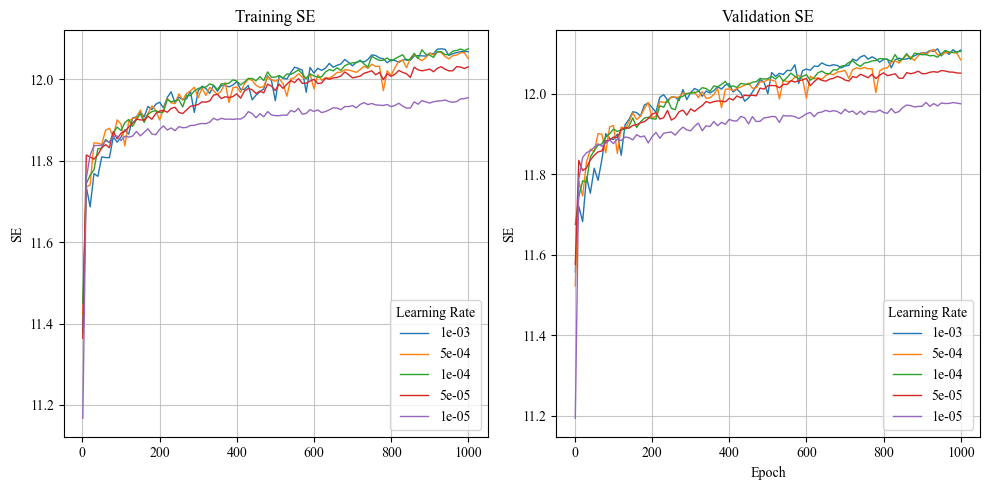

In [5]:
# Times New Roman 폰트 적용
# mpl.font_manager.fontManager.addfont('/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf')
plt.rcParams['font.family'] = 'Times New Roman'

# 에포크 1번과 에포크 번호가 10의 배수인 데이터만 선택합니다.
df_filtered = df[(df['epoch'] % 10 == 0) | (df['epoch'] == 1)]

# 고유 learning rate 값 추출
lr_values = df_filtered['lr'].unique()

# 2행 1열 서브플롯 생성 (x축 공유)
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True)

# 첫 번째 서브플롯: Training Loss
for lr in lr_values:
    subset = df_filtered[df_filtered['lr'] == lr]
    axes[0].plot(subset['epoch'], subset['train_loss'], label=f"{lr:.0e}", linewidth=1)
axes[0].set_title("Training SE")
axes[0].set_ylabel("SE")
axes[0].legend(title="Learning Rate")
axes[0].grid(True)
axes[0].grid(which='major', linestyle='-', linewidth=0.8, alpha=0.7)
axes[0].grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)

# 두 번째 서브플롯: Validation Loss
for lr in lr_values:
    subset = df_filtered[df_filtered['lr'] == lr]
    axes[1].plot(subset['epoch'], subset['val_loss'], label=f"{lr:.0e}", linewidth=1)
axes[1].set_title("Validation SE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("SE")
axes[1].legend(title="Learning Rate")
axes[1].grid(True)
axes[1].grid(which='major', linestyle='-', linewidth=0.8, alpha=0.7)
axes[1].grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join('result', 'loss_plot.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join('result', 'loss_plot.pdf'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join('result', 'loss_plot.eps'), dpi=300, bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


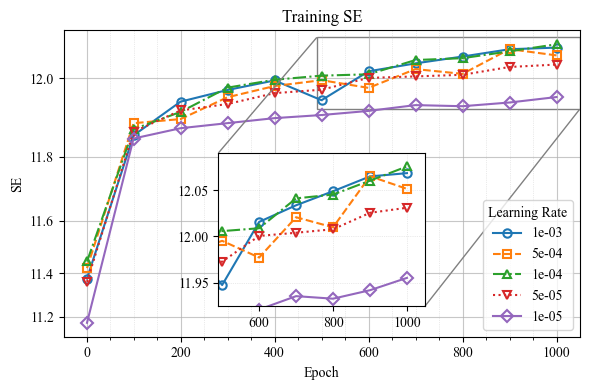

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


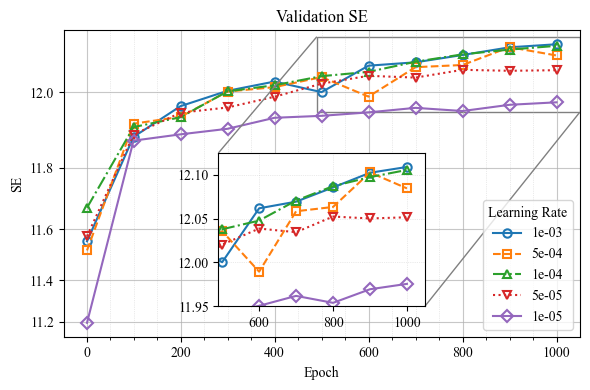

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
import os
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

# Times New Roman 폰트 설정
plt.rcParams['font.family'] = 'Times New Roman'

# 마지막 에폭 확인
max_epoch = df['epoch'].max()

# 데이터 필터링 (epoch 1, 100의 배수, 또는 마지막 에폭)
df_filtered = df[(df['epoch'] == 1) | (df['epoch'] % 100 == 0) | (df['epoch'] == max_epoch)]
lr_values = df_filtered['lr'].unique()

# 거듭제곱 지수 γ 설정 (γ > 1)
gamma = 1

# 변환 함수
forward = lambda y: np.exp(gamma * y)
inverse = lambda Y: np.log(Y) / gamma

# 마커와 라인 스타일 리스트
markers_list = ['o', 's', '^', 'v', 'D', 'x', 'p', '*']
linestyles_list = ['-', '--', '-.', ':']

def plot_single_metric(metric_col, title, filename, zoom_ylim=None):
    fig, ax = plt.subplots(figsize=(6, 4))
    
    # 스타일 사이클 생성
    marker_cycle = itertools.cycle(markers_list)
    linestyle_cycle = itertools.cycle(linestyles_list)

    for lr in lr_values:
        sub = df_filtered[df_filtered['lr'] == lr]
        ax.plot(sub['epoch'], sub[metric_col], 
                 label=f"{lr:.0e}", 
                 linewidth=1.5, 
                 marker=next(marker_cycle), 
                 linestyle=next(linestyle_cycle),
                 markersize=6,
                 markerfacecolor='none', # 마커 내부 비우기
                 markeredgewidth=1.5)    # 마커 테두리 두께

    
    ax.minorticks_on()
    plt.gca().set_yscale('function', functions=(forward, inverse))
    ax.grid(which='major', linestyle='-', linewidth=0.8, alpha=0.7)
    ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)

    # 레이블
    ax.set_title(title)
    ax.set_ylabel("SE")
    ax.set_xlabel("Epoch")
    ax.legend(title="Learning Rate", loc='lower right')

    # Inset (Zoom) 설정
    if zoom_ylim:
        # 위치 및 크기 설정 (x, y, width, height)
        axins = ax.inset_axes([0.3, 0.1, 0.4, 0.5]) 
        
        # Inset에 동일한 데이터 플롯
        marker_cycle = itertools.cycle(markers_list)
        linestyle_cycle = itertools.cycle(linestyles_list)
        
        for lr in lr_values:
            sub = df_filtered[df_filtered['lr'] == lr]
            axins.plot(sub['epoch'], sub[metric_col], 
                     label=f"{lr:.0e}", 
                     linewidth=1.5, 
                     marker=next(marker_cycle), 
                     linestyle=next(linestyle_cycle),
                     markersize=6,
                     markerfacecolor='none',
                     markeredgewidth=1.5)
        
        # 확대할 영역 설정
        axins.set_ylim(zoom_ylim[0], zoom_ylim[1])
        # X축은 마지막 50% 정도를 보여주도록 설정 (수렴 구간 확인용)
        axins.set_xlim(max_epoch * 0.49, max_epoch * 1.049)
        
        axins.grid(True, linestyle=':', linewidth=0.5, alpha=0.5)
        
        # 원본 그래프와 Inset 연결선 표시
        mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

    plt.tight_layout()
    plt.savefig(os.path.join('result', f'{filename}.png'), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join('result', f'{filename}.pdf'), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join('result', f'{filename}.eps'), dpi=300, bbox_inches='tight')
    plt.show()

# Training SE Plot
plot_single_metric('train_loss', 'Training SE', 'train_loss_plot', zoom_ylim=(11.925, 12.09))

# Validation SE Plot
plot_single_metric('val_loss', 'Validation SE', 'val_loss_plot', zoom_ylim=(11.95, 12.125))